**Import thư viện**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import cv2
from tqdm import tqdm

# **1. Tải dữ liệu**

In [ ]:
!gdown 1HXIWe_lP-0mP5s86rHOE1XUDAnyf_xQL

Downloading...
From (original): https://drive.google.com/uc?id=1HXIWe_lP-0mP5s86rHOE1XUDAnyf_xQL
From (redirected): https://drive.google.com/uc?id=1HXIWe_lP-0mP5s86rHOE1XUDAnyf_xQL&confirm=t&uuid=a2c8dd45-ca88-4f37-9640-7a53e80ff65b
To: /content/Kaggle – Skin Cancer MNIST HAM10000.zip
100% 2.78G/2.78G [00:37<00:00, 74.1MB/s]


In [ ]:
import zipfile
import shutil

zip_path = "/content/Kaggle – Skin Cancer MNIST HAM10000.zip"
extract_dir = "/content/HAM10000/"

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Giải nén hoàn tất!")

Giải nén hoàn tất!


In [ ]:
for root, dirs, files in os.walk(extract_dir):
    print(root, "—", len(files), "files")

/content/HAM10000/ — 1 files
/content/HAM10000/masks — 10015 files
/content/HAM10000/images — 10017 files


# **2. EDA và Cân bằng dữ liệu**

## **2.1. Đọc metadata CSV**

In [ ]:
csv_path = os.path.join(extract_dir, "GroundTruth.csv")
df = pd.read_csv(csv_path)

df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.columns

Index(['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC'], dtype='object')

Thêm đường dẫn ảnh vào DataFrame

In [ ]:
image_dir = os.path.join(extract_dir, "images")

df["image_path"] = df["image"].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

def get_diagnosis_label(row):
    diagnosis_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
    for col in diagnosis_cols:
        if row[col] == 1.0:
            return col
    return 'Unknown'

df['dx'] = df.apply(get_diagnosis_label, axis=1)

In [ ]:
df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,image_path,dx
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,/content/HAM10000/images/ISIC_0024306.jpg,NV
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,/content/HAM10000/images/ISIC_0024307.jpg,NV
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,/content/HAM10000/images/ISIC_0024308.jpg,NV
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,/content/HAM10000/images/ISIC_0024309.jpg,NV
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/HAM10000/images/ISIC_0024310.jpg,MEL


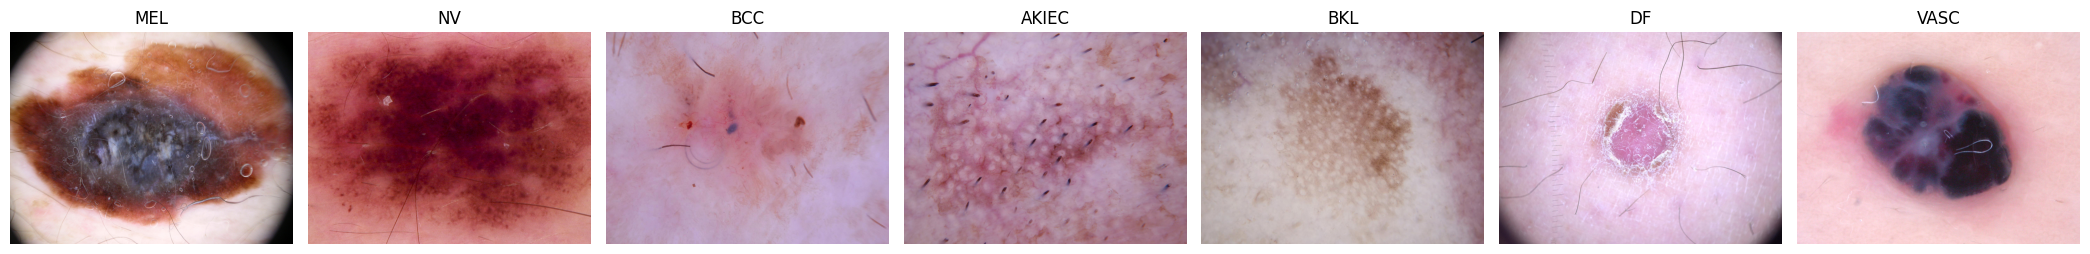

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

diagnosis_order = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

rows = []
for dx in diagnosis_order:
    tmp = df[df['dx'] == dx]
    if len(tmp) > 0:
        rows.append(tmp.sample(1, random_state=42))

sample = pd.concat(rows).reset_index(drop=True)

# Vẽ: mỗi ảnh 1 bệnh lý, không trùng
n = len(sample)
plt.figure(figsize=(3*n, 3))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## **2.2. Thống kê class ban đầu**

dx
AKIEC     327
BCC       514
BKL      1099
DF        115
MEL      1113
NV       6705
VASC      142
Name: count, dtype: int64


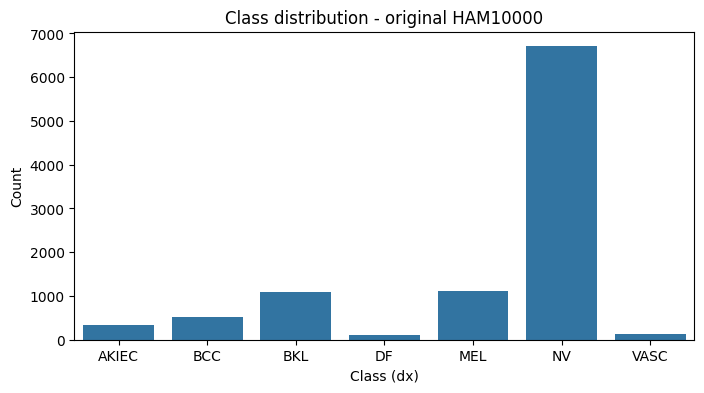

In [ ]:
class_counts = df["dx"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(8,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution - original HAM10000")
plt.xlabel("Class (dx)")
plt.ylabel("Count")
plt.show()

## **2.3. Cân bằng dữ liệu**
Quy tắc:
  * Minority classes: `AKIEC, BCC, DF, VASC` -> oversample lên 1000 ảnh mỗi lớp
  * `NV`: downsample còn 1300 ảnh.
  * `BKL, MEL` giữ nguyên số lượng gốc.
  * Tổng: 7512 ảnh.

In [ ]:
target_counts = {"AKIEC": 1000, "BCC": 1000, "DF": 1000, "VASC": 1000, "NV": 1300, "BKL"  : class_counts["BKL"], "MEL"  : class_counts["MEL"]}

balanced_parts = []
for cls, target in target_counts.items():
    df_cls = df[df["dx"] == cls]
    n_current = len(df_cls)

    if n_current >= target:
        # downsample
        df_bal = df_cls.sample(target, random_state=42)
    else:
        # oversample (nguyên tắc: augment sau -> ở đây chỉ nhân bản record)
        n_need = target - n_current
        df_extra = df_cls.sample(n_need, replace=True, random_state=42)
        df_bal = pd.concat([df_cls, df_extra], ignore_index=True)

    balanced_parts.append(df_bal)

df_balanced = pd.concat(balanced_parts, ignore_index=True)

print("Tổng số record sau khi cân bằng:", len(df_balanced))
df_balanced["dx"].value_counts().sort_index()

Tổng số record sau khi cân bằng: 7512


,count
dx,
AKIEC,1000
BCC,1000
BKL,1099
DF,1000
MEL,1113
NV,1300
VASC,1000


In [ ]:
print(df_balanced.columns)

Index(['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC', 'image_path',
       'dx'],
      dtype='object')


In [ ]:
[len(df),len(df_balanced)]

[10015, 7512]

## **2.4. Vẽ lại phân bố và lưu file cân bằng**

dx
AKIEC    1000
BCC      1000
BKL      1099
DF       1000
MEL      1113
NV       1300
VASC     1000
Name: count, dtype: int64


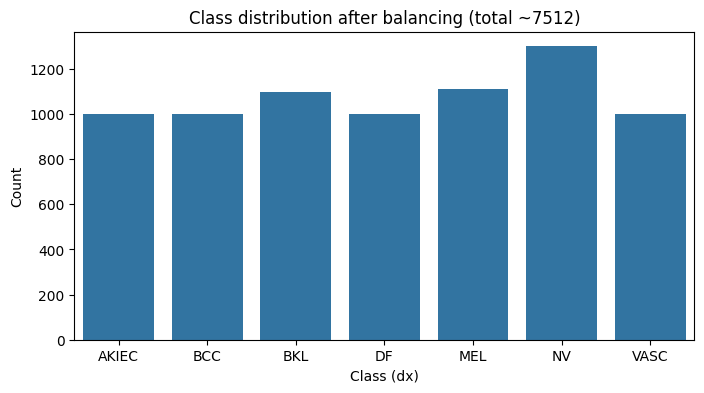

In [ ]:
balanced_counts = df_balanced["dx"].value_counts().sort_index()
print(balanced_counts)

plt.figure(figsize=(8,4))
sns.barplot(x=balanced_counts.index, y=balanced_counts.values)
plt.title("Class distribution after balancing (total ~7512)")
plt.xlabel("Class (dx)")
plt.ylabel("Count")
plt.show()

# Lưu phân bố để sau này đưa vào report PDF
balanced_counts.to_csv("/content/class_distribution_balanced.csv")

# Dữ liệu cân bằng tất cả dùng cái: df_balanced nhé ae.

3.

In [ ]:
class_names= ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
class_to_idx= {c: i for i, c in enumerate(class_names)}
print(class_to_idx)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


Gán label cho df_balaced

In [ ]:
df_balanced["label"]=df_balanced["dx"].map(class_to_idx)

Xáo trộn dữ liệu, đảm bảo khách quan

In [ ]:
df_balanced = df_balanced.sample(frac=1, random_state=42)
df_balanced.reset_index(drop=True, inplace=True)

In [ ]:
print(df_balanced.head(5))

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC  \
0  ISIC_0032428  0.0  1.0  0.0    0.0  0.0  0.0   0.0   
1  ISIC_0034031  0.0  0.0  0.0    0.0  1.0  0.0   0.0   
2  ISIC_0029654  0.0  1.0  0.0    0.0  0.0  0.0   0.0   
3  ISIC_0025417  0.0  0.0  1.0    0.0  0.0  0.0   0.0   
4  ISIC_0030708  0.0  1.0  0.0    0.0  0.0  0.0   0.0   

                                  image_path   dx  label  
0  /content/HAM10000/images/ISIC_0032428.jpg   NV      1  
1  /content/HAM10000/images/ISIC_0034031.jpg  BKL      4  
2  /content/HAM10000/images/ISIC_0029654.jpg   NV      1  
3  /content/HAM10000/images/ISIC_0025417.jpg  BCC      2  
4  /content/HAM10000/images/ISIC_0030708.jpg   NV      1  


In [ ]:
print(df_balanced.shape)

(7512, 11)


Cắt dataframe, chỉ lấy các cột: image_path, label.

In [ ]:
df_balanced = df_balanced[["image_path", "label"]]

In [ ]:
df_balanced.shape

(7512, 2)

In [ ]:
print(df_balanced.head(5))

                                  image_path  label
0  /content/HAM10000/images/ISIC_0032428.jpg      1
1  /content/HAM10000/images/ISIC_0034031.jpg      4
2  /content/HAM10000/images/ISIC_0029654.jpg      1
3  /content/HAM10000/images/ISIC_0025417.jpg      2
4  /content/HAM10000/images/ISIC_0030708.jpg      1


3.2 Chia dữ liệu thành 3 tập: train, val, test (Tỉ lệ 70/15/15)

In [ ]:
train_ratio = 0.7
val_ratio = 0.15
# Test ratio sẽ là phần còn lại (0.2)

# Tính vị trí cắt
n = len(df_balanced)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Cắt dữ liệu bằng .iloc
train_set = df_balanced.iloc[:train_end]
val_set = df_balanced.iloc[train_end:val_end]
test_set = df_balanced.iloc[val_end:]

print(f"Train: {len(train_set)} dòng")
print(f"Val: {len(val_set)} dòng")
print(f"Test: {len(test_set)} dòng")

Train: 5258 dòng
Val: 1127 dòng
Test: 1127 dòng


In [ ]:
train_set.head(5)

,image_path,label
0,/content/HAM10000/images/ISIC_0032428.jpg,1
1,/content/HAM10000/images/ISIC_0034031.jpg,4
2,/content/HAM10000/images/ISIC_0029654.jpg,1
3,/content/HAM10000/images/ISIC_0025417.jpg,2
4,/content/HAM10000/images/ISIC_0030708.jpg,1


3.3 Load và chuẩn hóa ảnh

In [ ]:
IMG_SIZE= 224
def load_image(path, label):
  img= tf.io.read_file(path)
  img= tf.image.decode_jpeg(img,channels=3)
  img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
  img = tf.cast(img, tf.float32)
  img= tf.keras.applications.efficientnet.preprocess_input(img)
  return img, label

Kiểm tra hoạt động của hàm load_image()

In [ ]:
result1, label1=load_image(df_balanced.image_path.iloc[0], df_balanced.label.iloc[0])


In [ ]:
r=np.array(result1)
print(r.shape)

(224, 224, 3)


Thử vẽ 1 ảnh đã được chuẩn hóa

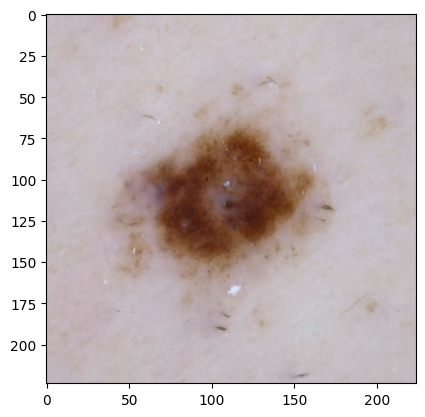

In [ ]:
plt.imshow(r.astype("uint8"))

Chuyển các tập train, validate, test về dạng tf.data.Dataset để mô hình có thể học được, do dữ liệu gốc là tập gồm rất nhiều ảnh nên nếu đọc thông thường sẽ tốn rất nhiều thời gian thậm chí chương trình có thể gãy


Với test set, tạo các Augmentations để áp dụng cho TTA khi dự đoán

In [ ]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_paths = train_set.iloc[:, 0].values  # Cột 0 là image_path
train_labels = train_set.iloc[:, 1].values # Cột 1 là label

# Tạo dataset từ slices
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

# Map hàm load_image (đọc ảnh, resize, preprocess)
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)

# Pipeline cho Train: Shuffle -> Batch -> Prefetch
# ✅ Shuffle quan trọng để model không học vẹt thứ tự
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
val_paths = val_set.iloc[:, 0].values
val_labels = val_set.iloc[:, 1].values

# Tạo dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

# Map hàm load_image
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)

# Pipeline cho Val: Batch -> Prefetch
# ❌ KHÔNG Shuffle tập Validation để kết quả đánh giá ổn định qua các epoch
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
test_paths = test_set.iloc[:, 0].values
test_labels = test_set.iloc[:, 1].values

# Tạo dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

# Map hàm load_image
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)

# Pipeline cho Test: Batch -> Prefetch
# ❌ KHÔNG Shuffle tập Test
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

4. Xây dựng EfficientNet-B0 ( Transfer Learning)

In [ ]:
#Tải mô hình
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

# 1. Định nghĩa kích thước ảnh đầu vào
# EfficientNet-B0 chuẩn hoạt động tốt nhất với kích thước 224x224
IMG_SHAPE = (224, 224, 3)

print("Đang tải mô hình EfficientNet-B0 từ server...")

# 2. Tải mô hình
base_model = EfficientNetB0(
    input_shape=IMG_SHAPE,
    include_top=False, # QUAN TRỌNG: Bỏ lớp output cũ (1000 lớp của ImageNet)
    weights='imagenet' # Tải trọng số đã được huấn luyện sẵn (giúp model thông minh hơn)
)

# 3. Đóng băng mô hình (Freeze)
# Bước này để đảm bảo khi mới train, ta không làm hỏng các kiến thức cũ của model
base_model.trainable = False
print("Completed!")

Đang tải mô hình EfficientNet-B0 từ server...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Completed!


Gắn thêm lớp output là 7 labels của bài toán

In [ ]:
from tensorflow.keras import layers, models

def build_final_model(base_model, num_classes=7):
    # 1. Tạo lớp Input
    inputs = layers.Input(shape=(224, 224, 3))

    # 2. Tích hợp Augmentation vào ngay trong Model
    # (Quan trọng: Model sẽ tự động tắt lớp này khi predict thường,
    # nhưng ta sẽ ép nó bật lên khi chạy TTA)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x) # Xoay ngẫu nhiên 20%
    x = layers.RandomZoom(0.2)(x)     # Zoom ngẫu nhiên 10%
    x = layers.RandomContrast(0.1)(x) # Thay đổi độ tương phản

    # 3. Đưa qua Base Model (EfficientNetB0)
    # training=False là BẮT BUỘC với EfficientNet để giữ nguyên các chỉ số BatchNormalization
    # ngay cả khi chúng ta unfreeze (xả đóng băng) sau này.
    x = base_model(x, training=False)

    # 4. Gắn các lớp đuôi (Head)
    x = layers.GlobalAveragePooling2D()(x) # Nén không gian
    x = layers.BatchNormalization()(x)     # Ổn định dữ liệu trước khi vào Dense

    # --- CHÌA KHÓA CỦA MC DROPOUT ---
    x = layers.Dropout(0.3)(x)             # Tắt ngẫu nhiên 30% neuron để chống học vẹt

    # 5. Lớp Output cuối cùng
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # 6. Khởi tạo Model hoàn chỉnh
    model = models.Model(inputs, outputs, name="EfficientNet_SkinCancer_TTA")
    return model

# Gọi hàm để tạo model
model = build_final_model(base_model, num_classes=7)

# In sơ đồ model để kiểm tra
model.summary()

Model: "EfficientNet_SkinCancer_TTA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,658 (15.50 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Huấn luyện mô hình với các layout mới

In [ ]:
# 1. Compile Model
model.compile(
    optimizer='adam', # Learning rate mặc định là 0.001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train Model (Giai đoạn 1: Chỉ train phần đầu)
# Vì train ít tham số nên chỉ cần khoảng 10-15 epochs là đủ
EPOCHS = 20

print(f"--- Bắt đầu huấn luyện {EPOCHS} epochs (Giai đoạn 1) ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

--- Bắt đầu huấn luyện 20 epochs (Giai đoạn 1) ---
Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 55s 222ms/step - accuracy: 0.3187 - loss: 2.0334 - val_accuracy: 0.5803 - val_loss: 1.2793
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 40s 216ms/step - accuracy: 0.5188 - loss: 1.3354 - val_accuracy: 0.6327 - val_loss: 1.0470
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 34s 180ms/step - accuracy: 0.5815 - loss: 1.1821 - val_accuracy: 0.6486 - val_loss: 0.9522
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 34s 177ms/step - accuracy: 0.5843 - loss: 1.1308 - val_accuracy: 0.6797 - val_loss: 0.9042
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 34s 175ms/step - accuracy: 0.6294 - loss: 1.0235 - val_accuracy: 0.6921 - val_loss: 0.8680
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 40s 173ms/step - accuracy: 0.6252 - loss: 1.0028 - val_accuracy: 0.6823 - val_loss: 0.8811
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 33s 170ms/step - accuracy: 0.6363 - loss: 1.0153 - val_accuracy: 0.6619 - val_loss: 0.9613
Epoch 8/20
165/165 ━━━━━━━━━━━━━

Thực hiện full fine-tunning

In [ ]:
# --- GIAI ĐOẠN 2: FULL FINE-TUNING (Xả băng toàn bộ) ---

# 1. Xả băng toàn bộ model (Theo yêu cầu báo cáo)
base_model.trainable = True
print("Đã xả băng toàn bộ EfficientNet! Số lượng tham số train sẽ tăng vọt.")

# 2. Compile lại với Learning Rate RẤT NHỎ
# Lưu ý: Đây là bước sống còn. Không dùng LR cũ (0.001) mà phải giảm xuống.
from tensorflow.keras import optimizers
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # 0.0001 (Theo báo cáo)
    loss='sparse_categorical_crossentropy', # Đảm bảo khớp với label của bạn
    metrics=['accuracy']
)

# 3. Tạo Checkpoint mới cho Giai đoạn 2
# Ta lưu tên khác để không đè mất model ngon của Giai đoạn 1
checkpoint_phase2 = ModelCheckpoint(
    filepath='best_model_phase2_finetuned.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

# EarlyStopping vẫn dùng lại cái cũ được (hoặc tạo cái mới nếu muốn kiên nhẫn hơn)
early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. Thiết lập số Epochs
# Báo cáo yêu cầu train thêm 15 epochs
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = 20 + FINE_TUNE_EPOCHS # Cộng dồn với 20 epoch cũ

print(f"--- Bắt đầu Fine-tuning {FINE_TUNE_EPOCHS} epochs tiếp theo ---")

# 5. Chạy Train tiếp
history_fine = model.fit(
    train_ds, # hoặc train_ds
    epochs=TOTAL_EPOCHS,
    initial_epoch=20, # Báo cho model biết ta bắt đầu từ epoch 20
    validation_data=val_ds, # hoặc val_ds
    callbacks=[checkpoint_phase2, early_stopping_phase2]
)

Đã xả băng toàn bộ EfficientNet! Số lượng tham số train sẽ tăng vọt.
--- Bắt đầu Fine-tuning 15 epochs tiếp theo ---
Epoch 21/35
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.4109 - loss: 1.9055
Epoch 21: val_loss improved from inf to 1.03818, saving model to best_model_phase2_finetuned.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 111s 410ms/step - accuracy: 0.4115 - loss: 1.9031 - val_accuracy: 0.6575 - val_loss: 1.0382
Epoch 22/35
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6438 - loss: 1.0462
Epoch 22: val_loss improved from 1.03818 to 0.91678, saving model to best_model_phase2_finetuned.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 79s 392ms/step - accuracy: 0.6439 - loss: 1.0457 - val_accuracy: 0.6957 - val_loss: 0.9168
Epoch 23/35
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.7073 - loss: 0.8184
Epoch 23: val_loss did not improve from 0.91678
165/165 ━━━━━━━━━━━━━━━━━━━━ 68s 384ms/step - accuracy: 0.7074 - loss: 0.8181 - val_accuracy: 0.6832 - val_loss: 0.9493
Epoch

Tải lại toàn bộ parameters tốt nhất từ bước fine-tunning

In [ ]:
# Tải lại trọng số tốt nhất của Giai đoạn 2
# Đảm bảo tên file khớp với cái bạn đã khai báo trong ModelCheckpoint
model.load_weights('best_model_phase2_finetuned.keras')
print("Đã tải lại trọng số tốt nhất của giai đoạn Fine-tuning!")

Thực hiện prediction

In [ ]:
import numpy as np
from tqdm import tqdm # Thư viện tạo thanh tiến trình cho đẹp
import tensorflow as tf

def predict_with_tta_mcdropout(model, dataset, n_times=10):
    """
    Dự đoán sử dụng TTA và MC Dropout.
    Input:
        - model: Model đã train
        - dataset: Test set (tf.data.Dataset)
        - n_times: Số lần lặp lại dự đoán cho mỗi ảnh (ví dụ: 5 lần)
    Output:
        - y_true: Nhãn thực tế
        - y_pred_probs: Xác suất dự đoán trung bình
    """
    y_true_all = []
    y_pred_probs_all = []

    print(f"--- Đang chạy TTA với {n_times} lần lặp (MC Dropout ON) ---")

    # Lặp qua từng batch trong test_ds
    for images, labels in tqdm(dataset):
        # Tạo biến tích lũy xác suất cho batch hiện tại
        # Shape: (batch_size, 7 class)
        batch_probs_sum = np.zeros((images.shape[0], 7))

        # Lặp n_times lần dự đoán
        for _ in range(n_times):
            # QUAN TRỌNG: training=True để BẬT RandomAugmentation và Dropout
            # Dù training=True, nhưng EfficientNet bên trong vẫn đóng băng BatchNorm (do ta đã config trước đó)
            probs = model(images, training=True) #Bật Dropout cho quá trình dự đoán (MC Dropout))
            batch_probs_sum += probs.numpy()

        # Tính trung bình cộng
        batch_probs_avg = batch_probs_sum / n_times

        # Lưu kết quả
        y_true_all.append(labels.numpy())
        y_pred_probs_all.append(batch_probs_avg)

    # Nối các batch lại thành mảng lớn
    y_true = np.concatenate(y_true_all)
    y_pred_probs = np.concatenate(y_pred_probs_all)

    return y_true, y_pred_probs

# --- THỰC HIỆN DỰ ĐOÁN ---
# Số lần TTA càng cao thì càng chính xác nhưng càng lâu.
# n_times=5 hoặc 10 là con số cân bằng tốt.
y_true, y_probs = predict_with_tta_mcdropout(model, test_ds, n_times=10)

# Lấy nhãn có xác suất cao nhất
y_pred = np.argmax(y_probs, axis=1)

print("\nĐã hoàn thành dự đoán!")

--- Đang chạy TTA với 10 lần lặp (MC Dropout ON) ---


100%|██████████| 36/36 [02:35<00:00,  4.31s/it]


Đã hoàn thành dự đoán!


🚀 TTA Accuracy: 0.8705

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

       akiec       0.73      0.73      0.73       161
         bcc       0.85      0.79      0.82       205
         bkl       0.94      0.93      0.94       147
          df       0.81      0.96      0.88       134
         mel       0.80      0.75      0.77       172
          nv       0.98      1.00      0.99       153
        vasc       0.99      1.00      1.00       155

    accuracy                           0.87      1127
   macro avg       0.87      0.88      0.87      1127
weighted avg       0.87      0.87      0.87      1127



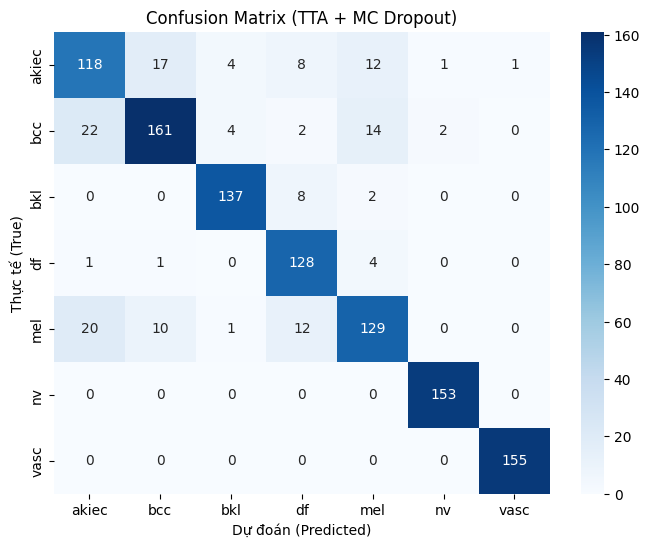

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"🚀 TTA Accuracy: {acc:.4f}")

# 2. Classification Report (Chi tiết từng loại bệnh)
# Mapping tên các loại bệnh (theo thứ tự 0-6)
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
# Lưu ý: Cần đảm bảo thứ tự này khớp với lúc bạn encode dữ liệu ban đầu.
# Nếu bạn dùng LabelEncoder của sklearn thì thứ tự là Alphabet.

print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (True)')
plt.title('Confusion Matrix (TTA + MC Dropout)')
plt.show()